In [1]:
 # %% veri setinin yüklenmesi ve preprocessing
from keras.datasets import mnist #load mnist
from keras.utils import to_categorical #kategorik verilere cevirme
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.models import Sequential # Sıralı model
from keras.layers import Dense #katmanlar
from keras.models import load_model

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
#mnist veri setini ükle,
(x_train, y_train),(x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


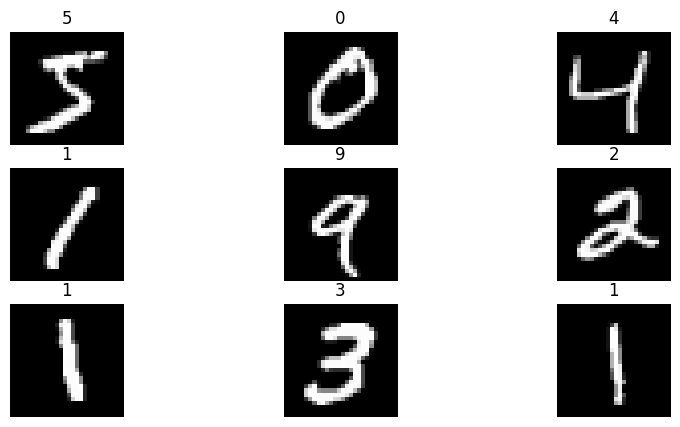

In [3]:
#ilk bir kaç tane örneği görselleştir
plt.figure(figsize=(10,5))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(x_train[i],cmap='gray')
  plt.title(y_train[i])
  plt.axis('off')
plt.show()

In [4]:
# verileri normalize edelim. 0-255 aralığındaki piksel değerlerini 0 - 1 aralığına getirelim. ve 28*28 i 784 *1 yapalım.
x_train = x_train.reshape(60000, 784).astype('float32') / 255
x_test = x_test.reshape(10000, 784).astype('float32') / 255

# etiketleri kategorik hale cevirelim.  one hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [5]:
# %% AN modelinin olusturalmasi ve derlenmesi
model=Sequential()
#ilk katman 512 cell, relu aktivasyon fonksiyonu input boyuru da 28*28
model.add(Dense(512,activation="relu",input_shape = (28*28,)))

#ikinci katman 256 cell aktivasyon tanh
model.add(Dense(256,activation="tanh"))

#output layer 10 tane olmak zorunda aktivasyon softmax olmak zorunda
model.add(Dense(10,activation="softmax"))

model.summary()

# model derlemesi optimezer( adam : buyuk veri ve komplex aglar icin idealdir)
# model derlemesi : loos (categorical_crossentropy)
# model derlemesi : metrik(accuracy)
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# %% callback'lerin tanimlanmasi ve Ann egitilmesi

# Erken durdurma eger val_loss iyilesmiyorsa egitimi durduralim.
# monitor: dogrulama setindeki (val) kaybi (loss) izler
# patience: 3->3 epeoch boyunca vall loss degismiyorsa erken durdurma yap
# restore_best_weights en iyi modelin agirliklari geri yukler

early_stopping=EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# model cheackpoint : en iyi modelin agirliklarini kaydeder
# save_best_only : sadece en iyi perfromans gosteren modeli kaydeder.
checkpoint = ModelCheckpoint("ann_best_model.h5",monitor="val_loss",save_best_only=True)

#model training: 10 epochs , batch size = 60, validation set oranı = %20
#model 60000 veri setini her birini 60 parçadan oluşan 1000 kerede train edecek ve biz buna bir epoch diyeceğiz.
# ama biz valdaition için %20 si ayirdigimizdan 48000 taneyi 60 parça olarak yollayacagiz
history= model.fit(x_train,y_train, #train veri seti
          epochs=10, # model toplamda 10 kere veri setini görecek, veri seti 10 kere egitlecek
          batch_size=60, #veri setinin modele kaçarlı parçalarla verileceği . 60 lı parçalarla gönderilecek modele
          validation_split=0.2, # egitim verisinin %20si dogrulama verisi olarak kullanilacak
          callbacks=[early_stopping,checkpoint])


Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8905 - loss: 0.3638

800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9373 - loss: 0.2078 - val_accuracy: 0.9695 - val_loss: 0.1017
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9740 - loss: 0.0826 - val_accuracy: 0.9689 - val_loss: 0.1042
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9828 - loss: 0.0535 - val_accuracy: 0.9684 - val_loss: 0.1050
Epoch 4/10
797/800 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9873 - loss: 0.0380

800/800 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9878 - loss: 0.0369 - val_accuracy: 0.9757 - val_loss: 0.0873
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9889 - loss: 0.0333 - val_accuracy: 0.9747 - val_loss: 0.0957
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9930 - loss: 0.0218 - val_accuracy: 0.9765 - val_loss: 0.0920
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9931 - loss: 0.0193 - val_accuracy: 0.9780 - val_loss: 0.0925


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9766 - loss: 0.0825
Test_acc: 0.9765999913215637, test_loss: 0.08253821730613708


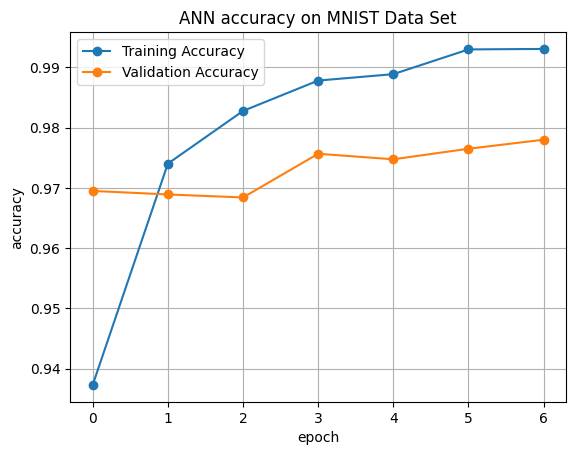

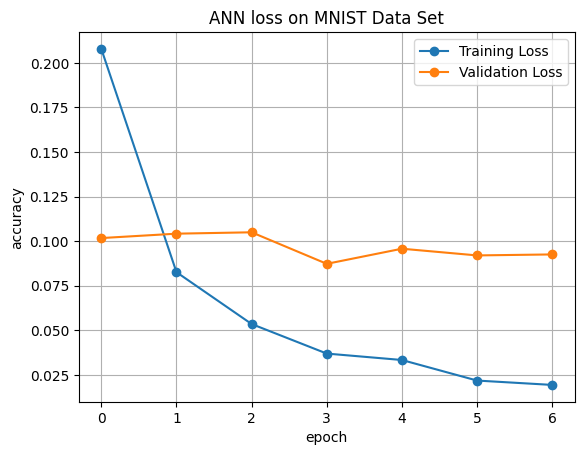

In [7]:
# %% model evaulation görsellestirme , model save and load

# test verisi üzerinde model performansi degerlendirme
#evaluate modelin test verisi üzerindeki kaybini(test_loss) ve dogrulugunu(test_acc) hesaplar.
test_loss, test_acc = model.evaluate(x_test,y_test)
print(f"Test_acc: {test_acc}, test_loss: {test_loss}")

#training amd validation accuracy gorsellestir
plt.figure()
plt.plot(history.history["accuracy"],marker="o",label="Training Accuracy")
plt.plot(history.history["val_accuracy"],marker="o",label="Validation Accuracy")
plt.title("ANN accuracy on MNIST Data Set")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend()
plt.grid()
plt.show()


#training and validation görselleştirm
plt.figure()
plt.plot(history.history["loss"],marker="o",label="Training Loss")
plt.plot(history.history["val_loss"],marker="o",label="Validation Loss")
plt.title("ANN loss on MNIST Data Set")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend()
plt.grid()
plt.show()

In [8]:
#modeli kaydetme
model.save("final_kereas_mnist_ann_model.h5")

In [9]:
loaded_model = load_model("final_kereas_mnist_ann_model.h5")

In [11]:
#yüklü modeli ileride kullanma
Loaded_model_test_loss, Loaded_model_test_acc = loaded_model.evaluate(x_test,y_test)
print(f"Loaded_model_Test_acc: {Loaded_model_test_acc}, Loaded_model_test_loss: {Loaded_model_test_loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9766 - loss: 0.0825
Loaded_model_Test_acc: 0.9765999913215637, Loaded_model_test_loss: 0.08253821730613708
